In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'pandas'

In [ ]:
df = pd.read_csv("height-weight.csv")
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


Text(0, 0.5, 'height')

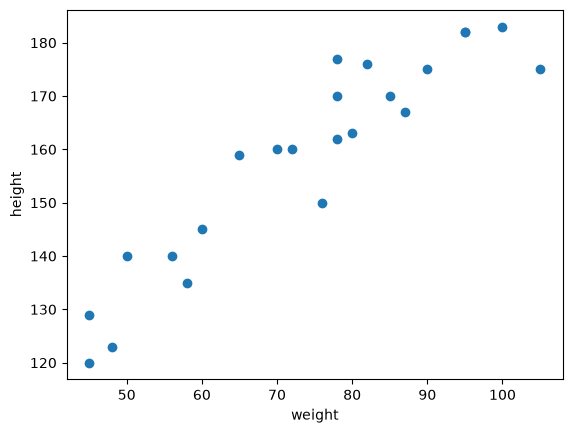

In [ ]:
# scatteer plot 

plt.scatter(df['Weight'], df['Height'])
plt.xlabel("weight")
plt.ylabel("height")

In [ ]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


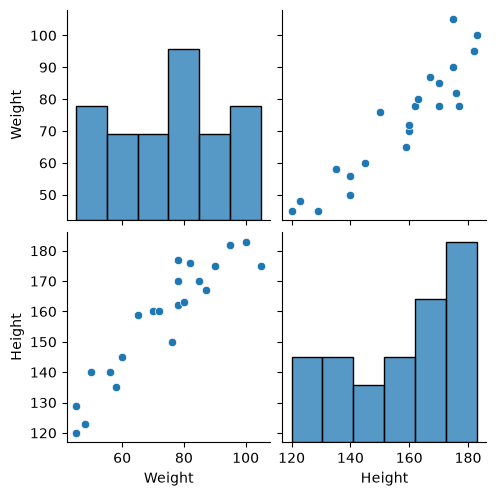

In [ ]:
# seaborn 
import seaborn as sns

sns.pairplot(df)

In [ ]:
# step -1 
# Making the independent and dependent features 
X = df[['Weight']]## always the independent feature should be datframe or 2 dimentional array 


In [ ]:
type(X)
# the X will in the dataframe 

pandas.DataFrame

In [ ]:
# dependent feature can be a feature 

y= df["Height"] # this can be in series or else in 1 dim array 

In [ ]:
# Train Test Split 
from sklearn.model_selection import train_test_split 
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size= 0.25, random_state = 42)

In [ ]:
X_train.shape

(17, 1)

In [ ]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# basically used to make the both features to have the same units this will make the mean 0 and variance 1 

In [ ]:
X_train = scaler.fit_transform (X_train)

In [ ]:
X_test = scaler.transform(X_test)
# always remember that you need to do the scalar.transform to the testing data but not to the testing data because here data lekage may occur so training data need to be in fit_transform 

In [ ]:
# Apply Simple Linear regression
from sklearn.linear_model import LinearRegression

regression= LinearRegression(n_jobs=-1)


In [ ]:
regression.fit(X_train , y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.3]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,156.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [ ]:
print("Co efficient or slope: " ,regression.coef_)


Co efficient or slope:  [17.2982057]


In [ ]:
print("Intercept : " ,regression.intercept_)

Intercept :  156.47058823529412


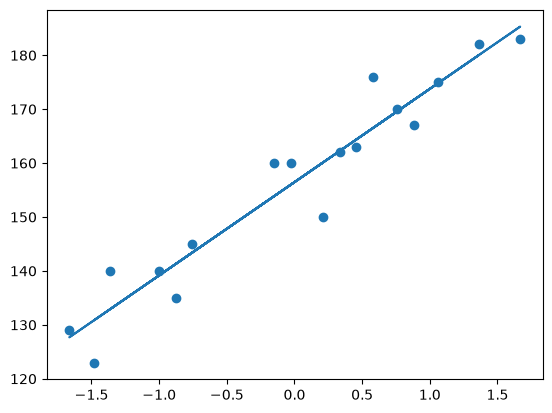

In [ ]:
# plot traing data best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))

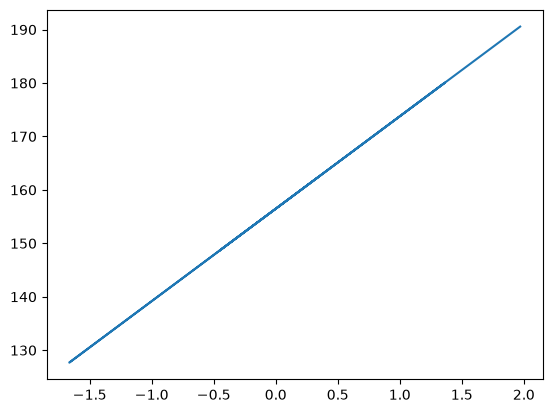

In [ ]:
# prediction for the test data 
plt.plot(X_test , regression.predict(X_test))

In [ ]:
y_pred = regression.predict(X_test)

### Predection of the test data
1. Predicted height output = intercept + coef_(Weights)
2. y_pred_test = 156.47 +  17.29(X_test)

In [ ]:
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

print("y_test:", y_test)
print("y_pred:", y_pred)

y_test shape: (6,)
y_pred shape: (6,)
y_test: 15    177
9     170
0     120
8     182
17    159
12    175
Name: Height, dtype: int64
y_pred: [162.26499721 162.26499721 127.68347133 180.07972266 148.64197186
 190.55897293]


In [ ]:
# performance Metrices 

from sklearn.metrics import mean_absolute_error , mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mse)

print(mse ,mae , rmse)

114.84069295228699 9.66512588679501 10.716374991212605
